#### $Importación$ $librerias$

In [1]:
%pip install plotly openpyxl nbformat


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import sys
!{sys.executable} -m pip install nbformat


In [3]:
# importamos la librerías necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
import openpyxl
import nbformat

#### $Cargar$ $Dataset$

In [4]:
# Estilo de gráficas
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Cargar el dataset procesado
ruta_data = "../data/data_procesada/Dataset_avaluos_final.xlsx"
df = pd.read_excel(ruta_data)

print(f"Dataset cargado: {df.shape} registros y {df.shape} variables.")
df.head()

Dataset cargado: (1000, 47) registros y (1000, 47) variables.


,Entidad avaluadora,ID avaluo,Perito,Nombre solicitante,ID solicitante,Fecha avaluo,Departamento,Ciudad,Codigo DANE,Direccion,...,Zonas verdes,Parquetadero visitantes,Arborización,Area total,Area privada,Valor catastral,Valor comercial,valor_m2,error_area,Parquedadero visitantes
0,Grupo Herz,102030000,Nubia Luz Gómez Ramírez,Eduardo Vanegas Gómez,94871726,2025-06-11,Cundinamarca,BOGOTÁ,11001,Carrera 130R # 3-50,...,0,0,0,134,130,351752052,1172506843,8.750051e+06,False,NaN
1,Avalúos Pro,102030001,Elkin Alonso Jiménez,Manuel César Sierra,63494669,2025-10-05,Cundinamarca,BOGOTÁ,11001,Calle 67 # 68-23,...,1,0,0,222,218,304008233,1013360778,4.564688e+06,False,NaN
2,Inmuebles SAS,102030002,Liliana Maritza Niño,Lucía Núñez,43272790,2025-06-05,Cundinamarca,BOGOTÁ,11001,Cr. 9ª # 8-73,...,1,1,1,104,102,237159063,790530212,7.601252e+06,False,NaN
3,Inmuebles SAS,102030003,Andrés Meza Ramírez,Jaime González,71928459,2025-10-28,Cundinamarca,BOGOTÁ,11001,Calle 76 # 76O-5 Este,...,0,1,0,80,76,99874591,332915305,4.161441e+06,False,NaN
4,Inmuebles SAS,102030004,Juan Salazar Flórez,Isabel Calderón Cano,88281429,2026-01-22,Cundinamarca,BOGOTÁ,11001,Avenida Sebastián Steven Martínez Pinzón # 7-7...,...,0,0,0,168,165,225753419,752511397,4.479235e+06,False,NaN


#### $Diagnostico$ $(Calidad$ $de$ $datos)$

In [5]:
# 1. Verificación de Nulos
null_report = df.isnull().sum()
null_report = null_report[null_report > 0]
print("Variables con datos faltantes:\n", null_report)

# 2. Verificación de errores lógicos (Usando tu flag de Area)
if 'error_area' in df.columns:
    errores = df['error_area'].sum()
    print(f"\nAlerta: Se detectaron {errores} registros con inconsistencia en áreas (Privada > Total).")

Variables con datos faltantes:
 Nombre edificio             482
Barrio                       32
Tipo garaje                 336
Parquedadero visitantes    1000
dtype: int64

Alerta: Se detectaron 0 registros con inconsistencia en áreas (Privada > Total).


#### $Distribución$ $del$ $Mercado$ $(Univariado)$

In [6]:
fig = px.histogram(df, x="Valor comercial", 
                   title="Distribución de Precios de Venta",
                   nbins=30, 
                   color_discrete_sequence=['#2ecc71'])
fig.show()

# Boxplot para detectar Outliers en Valor por Metro Cuadrado
fig2 = px.box(df, x="Estrato", y="valor_m2", 
              title="Detección de Outliers: Valor m² por Estrato",
              color="Estrato")
fig2.show()

#### $Correlaciones$ $(Multivariado)$

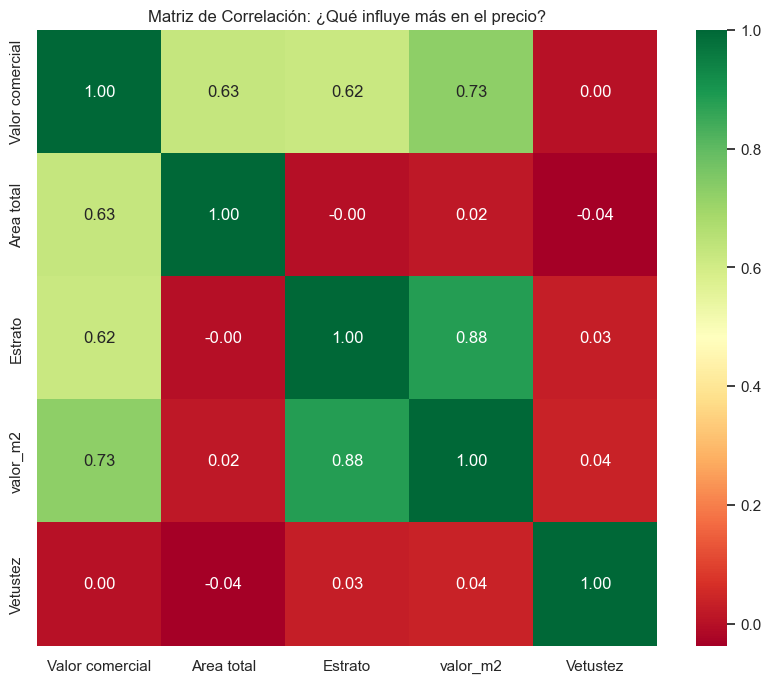

In [7]:
# Seleccionamos solo las variables numéricas clave para el calor
cols_interes = ['Valor comercial', 'Area total', 'Estrato', 'valor_m2', 'Vetustez']
corr = df[cols_interes].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Matriz de Correlación: ¿Qué influye más en el precio?")
plt.show()